## Case Study: Transition from Stratocumulus Clouds to Cumulus Clouds 

#### Load libraries and modules

In [1]:
import earthaccess
import xarray as xr
import netCDF4, os, re, copy, glob
import numpy as np
import matplotlib.pyplot as plt
import pickle
import cartopy
import sys,os,glob,datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import seaborn as sns
import datetime
import PACE_Util
from matplotlib.colors import ListedColormap

import warnings
warnings.filterwarnings("ignore")

### Download Data  

In [2]:
auth = earthaccess.login(persist=True)

In [3]:
# results = earthaccess.search_datasets(instrument="harp2")
# for item in results:
#     summary = item.summary()
#     print(summary["short-name"])

In [4]:
results = earthaccess.search_data(
    short_name="PACE_HARP2_L2_CLOUD_GPC", 
    # temporal=("2025-07-01", "2025-07-31"),
    temporal=("2025-07-06T19:20:50", "2025-07-06T19:25:49"),
    count=1
)
print(len(results))

In [6]:
files = earthaccess.download(results, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L2_CLOUD_GPC_v3_0")

### Load HARP-2 and OCI cloud retrievals

In [2]:
PACE_data_path = '/umbc/rs/pi_zzbatmos/common/Data/PACE/'
PACE_OCI_CLD_ANC_Level1C_path = 'PACE_OCI_CLD_ANC_Level-1C/'
HARP2_CLD_path = 'PACE_HARP2_GPC_Level-1C/'

In [3]:
def extract_timestamps(file_paths):
    # Regular expression to match the timestamp (YYYYMMDDTHHMMSS)
    pattern = r'\d{8}T\d{6}'
    
    # List to store extracted timestamps
    timestamps = []
    for path in file_paths:
        # Search for the timestamp in the file path
        match = re.search(pattern, path)
        if match:
            timestamps.append(match.group(0))
    
    return timestamps

### Find all the HARP-2 cloud retrieval files and the corresponding OCI cloud files

In [4]:
HARP2_CLD_files=glob.glob(os.path.join(PACE_data_path, HARP2_CLD_path, '*.nc'))
HARP2_CLD_timestamp = extract_timestamps(HARP2_CLD_files)

In [5]:
# List to store pairs of matching HARP2 and OCI file paths
OCI_CLD_files = []

# Create a dictionary to map timestamps to HARP2 file paths for easy lookup
timestamp_to_harp2 = dict(zip(HARP2_CLD_timestamp, HARP2_CLD_files))

# List to store timestamps that have matching OCI files
kept_timestamps = []

# Search for matching OCI files
for timestamp in HARP2_CLD_timestamp:
    # Search for OCI files with the same timestamp
    oci_files = glob.glob(os.path.join(PACE_data_path, PACE_OCI_CLD_ANC_Level1C_path, f'*{timestamp}*.nc'))
    
    # If matching OCI files are found, store the pair
    if oci_files:
        harp2_file = timestamp_to_harp2[timestamp]
        for oci_file in oci_files:
            OCI_CLD_files.append((oci_file))
        kept_timestamps.append(timestamp)

# Update HARP2_CLD_timestamp to only include timestamps with matching OCI files
HARP2_CLD_timestamp[:] = kept_timestamps
# Trim HARP2_CLD_files to only include files with timestamps in kept_timestamps
HARP2_CLD_files[:] = [file for file in HARP2_CLD_files if any(timestamp in file for timestamp in kept_timestamps)]

In [6]:
print(len(kept_timestamps), len(HARP2_CLD_files), len(OCI_CLD_files))

2650 2650 2650


## A case study

In [7]:
target_timestamp='20250706T192050'
idx = kept_timestamps.index(target_timestamp)
print(idx)

798


In [8]:
HARP2_CLD = PACE_Util.HARP2_L2_CLD(target_timestamp,os.path.join(PACE_data_path, HARP2_CLD_path))

In [9]:
OCI_CLD =  PACE_Util.OCI_CLD_ANC(target_timestamp,os.path.join(PACE_data_path, PACE_OCI_CLD_ANC_Level1C_path))

### Plot the HARP-2 Cloud Effective Radius retrieval

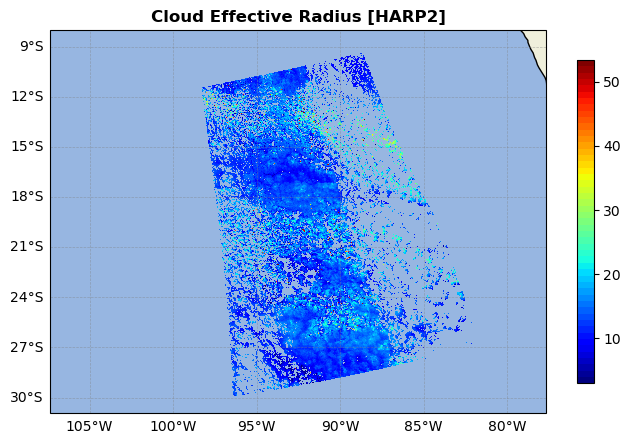

In [10]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap_name='jet'

data = HARP2_CLD.retr.cloud_bow_droplet_effective_radius
cmap = plt.get_cmap(cmap_name, np.nanmax(data) - np.nanmin(data) + 1)

mat = ax.pcolormesh(HARP2_CLD.geo.longitude, HARP2_CLD.geo.latitude, data, transform=ccrs.PlateCarree(), cmap=cmap,
                    # vmin=np.nanmin(data) - 0.5, vmax=np.nanmax(data) + 0.5, 
                    shading="nearest", rasterized=True)

ax.set_aspect("equal")
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Cloud Effective Radius [HARP2]', fontsize=12, color='k', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
# cax = plt.colorbar(mat, ax=ax, ticks=np.arange(np.nanmin(data), np.nanmax(data) + 1, 5))
cax = plt.colorbar(mat, ax=ax, shrink=0.7)

### Plot the Cloud Bow Effective Variance retrieval

In [11]:
print(np.nanmax(data))

53.36896


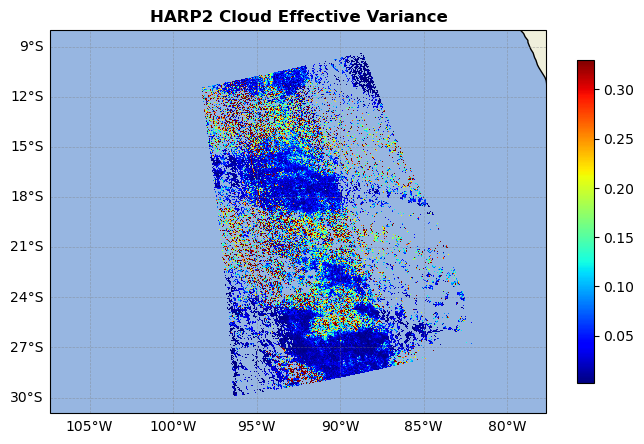

In [12]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap_name='jet'

data = HARP2_CLD.retr.cloud_bow_droplet_effective_variance
cmap = plt.get_cmap(cmap_name, np.nanmax(data) - np.nanmin(data) + 1)

mat = ax.pcolormesh(HARP2_CLD.geo.longitude, HARP2_CLD.geo.latitude, data, transform=ccrs.PlateCarree(),
                     cmap=cmap_name, vmax=0.33, shading="nearest", rasterized=True)
ax.set_aspect("equal")
ax.set_aspect("equal")
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('HARP2 Cloud Effective Variance', fontsize=12, color='k', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
# cax = plt.colorbar(mat, ax=ax, ticks=np.arange(np.nanmin(data), np.nanmax(data), 0.02))
cax = plt.colorbar(mat, ax=ax, shrink=0.7)

### Plot the OCI Cloud effective radius retrieval

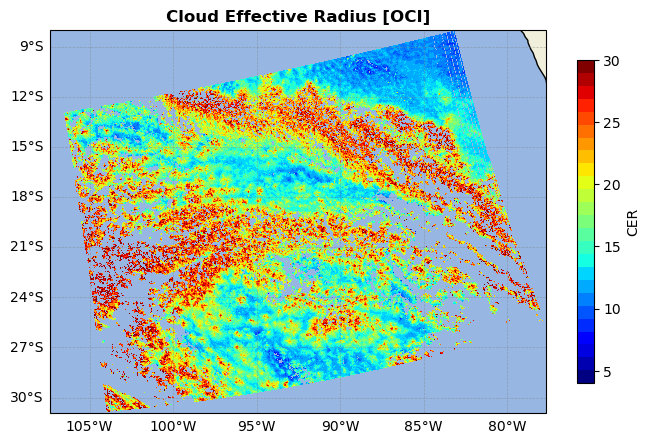

In [13]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap_name='jet'

data = OCI_CLD.ds.cer_21_water_cloud.values
cmap = plt.get_cmap(cmap_name, np.nanmax(data) - np.nanmin(data) + 1)

mat = ax.pcolormesh(OCI_CLD.ds.longitude, OCI_CLD.ds.latitude, data, transform=ccrs.PlateCarree(), cmap=cmap, 
                    vmin=4, vmax=30, shading="nearest", rasterized=True)
                    # vmin=np.nanmin(data) - 0.5, vmax=np.nanmax(data) + 0.5, 
ax.set_aspect("equal")
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Cloud Effective Radius [OCI]', fontsize=12, color='k', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
# cax = plt.colorbar(mat, ax=ax,ticks=np.arange(np.nanmin(data), np.nanmax(data) + 1, 5))
cax = plt.colorbar(mat, ax=ax, shrink=0.7, label="CER")

# plt.savefig("Map_OCI.png", dpi=500, bbox_inches="tight")

In [16]:
HARP2_CLD.retr.cloud_bow_droplet_effective_radius.shape

(396, 519)

In [17]:
OCI_CLD.ds.cer_21_water_cloud.shape

(396, 519)

In [18]:
OCI_CER = OCI_CLD.ds.cer_21_water_cloud.values
HARP2_CER = HARP2_CLD.retr.cloud_bow_droplet_effective_radius.values
HARP2_CEV = HARP2_CLD.retr.cloud_bow_droplet_effective_variance.values

mask_all = (HARP2_CER > 0) & (OCI_CER > 0) 
mask_small_cev = (OCI_CER > 0) & (HARP2_CER > 0) & (HARP2_CEV<0.1)
mask_large_cev = (OCI_CER > 0) & (HARP2_CER > 0) & (HARP2_CEV>0.3)

## Collocated data

In [19]:
# Find red dot pixel
lat_target = -19 # -20.0   # -18.0
lon_target = -91 # -91.5   # -91.85

lat = OCI_CLD.ds.latitude.values   
lon = OCI_CLD.ds.longitude.values  

# compute squared distance to target
dist = (lat - lat_target)**2 + (lon - lon_target)**2

# find nearest pixel
iy, ix = np.where(dist == np.min(dist))

print("Red dot pixel:", ix[0], iy[0])

Red dot pixel: 304 207


In [20]:
y0,x0 = 207,304 
# y0,x0 = 231,292 
y1,x1 = 188,289 

CER of pixel red: nan μm
COT of pixel red: nan

CER of pixel black: 25.38 μm
COT of pixel black: 3.67


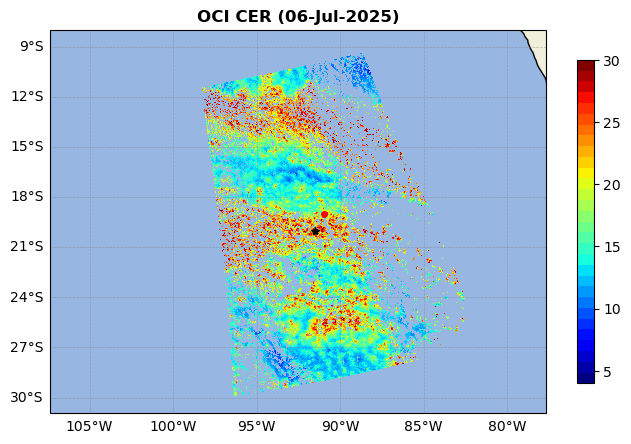

In [21]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap_name='jet'

data = np.where(mask_all, OCI_CLD.ds.cer_21_water_cloud.values, np.nan)   
cmap = plt.get_cmap(cmap_name, 30)

mat = ax.pcolormesh(OCI_CLD.ds.longitude.values, OCI_CLD.ds.latitude.values, data, transform=ccrs.PlateCarree(),
                     cmap=cmap, vmin=4, vmax= 30, shading="nearest", rasterized=True)
ax.plot(OCI_CLD.ds.longitude.values[y0, x0], OCI_CLD.ds.latitude.values[y0, x0], marker='o', color='r',
        markersize=4, transform=ccrs.PlateCarree(), zorder=5)
ax.plot(OCI_CLD.ds.longitude.values[y1, x1], OCI_CLD.ds.latitude.values[y1, x1], marker='*', color='k',
        markersize=6, transform=ccrs.PlateCarree(), zorder=5)

ax.set_aspect("equal")
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('OCI CER (06-Jul-2025)', fontsize=12, color='k', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cax = plt.colorbar(mat, ax=ax, shrink=0.7)
# cax = plt.colorbar(mat, ax=ax, ticks=np.arange(vmin, vmax + 1, 5))
# cax = plt.colorbar(mat, ax=ax, ticks = np.linspace(vmin, vmax, num=int((vmax - vmin) / 5) + 1))

print(f'CER of pixel red: {OCI_CLD.ds.cer_21_water_cloud[y0,x0].values:.2f} μm')
print(f'COT of pixel red: {OCI_CLD.ds.cot_21_water_cloud[y0,x0].values:.2f}')
print('')
print(f'CER of pixel black: {OCI_CLD.ds.cer_21_water_cloud[y1,x1].values:.2f} μm')
print(f'COT of pixel black: {OCI_CLD.ds.cot_21_water_cloud[y1,x1].values:.2f}')

# plt.savefig("Map_OCI.png", dpi=500, bbox_inches="tight")

CER of pixel red: 20.11 μm
CER of pixel black: 18.18 μm


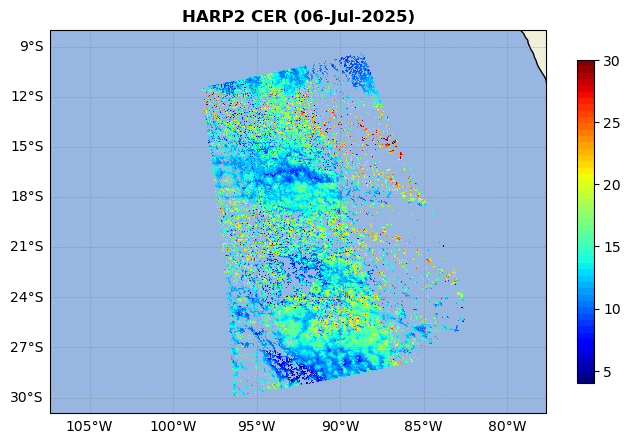

In [26]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap_name='jet'

data = np.where(mask_all, HARP2_CLD.retr.cloud_bow_droplet_effective_radius.values, np.nan)    
cmap = plt.get_cmap(cmap_name, np.nanmax(data) - np.nanmin(data) + 1)

vmin, vmax= 4, 30
mat = ax.pcolormesh(OCI_CLD.ds.longitude.values, OCI_CLD.ds.latitude.values, data, transform=ccrs.PlateCarree(),
                     cmap=cmap, vmin=vmin, vmax=vmax, shading="nearest", rasterized=True)
# ax.plot(OCI_CLD.ds.longitude.values[y0, x0], OCI_CLD.ds.latitude.values[y0, x0], marker='o', color='r',
#         markersize=4, transform=ccrs.PlateCarree(), zorder=5)
# ax.plot(OCI_CLD.ds.longitude.values[y1, x1], OCI_CLD.ds.latitude.values[y1, x1], marker='*', color='k',
#         markersize=6, transform=ccrs.PlateCarree(), zorder=5)
ax.set_aspect("equal")
ax.set_aspect("equal")
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('HARP2 CER (06-Jul-2025)', fontsize=12, color='k', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cax = plt.colorbar(mat, ax=ax, shrink=0.7)
# cax = plt.colorbar(mat, ax=ax, ticks=np.arange(vmin, vmax + 1, 5))

# plt.savefig("Map_HARP2.png", dpi=500, bbox_inches="tight")

print(f'CER of pixel red: {HARP2_CLD.retr.cloud_bow_droplet_effective_radius[y0,x0].values:.2f} μm')
print(f'CER of pixel black: {HARP2_CLD.retr.cloud_bow_droplet_effective_radius[y1,x1].values:.2f} μm')

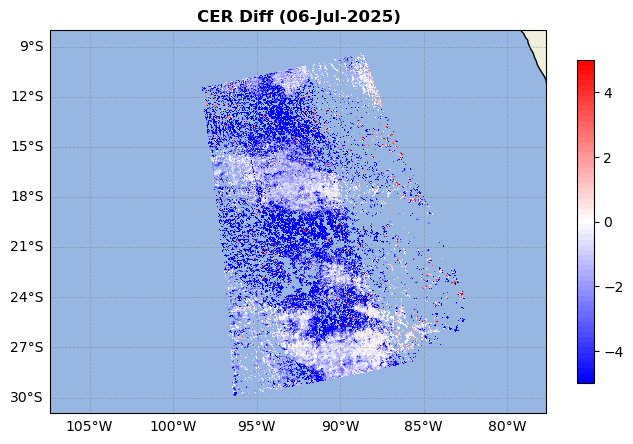

In [23]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap_name='bwr'
 
CER_diff= HARP2_CLD.retr.cloud_bow_droplet_effective_radius.values - OCI_CLD.ds.cer_21_water_cloud.values
data = np.where(mask_all, CER_diff, np.nan) #OCI_CLD.ds.cer_21_water_cloud.values[mask_all]
cmap = plt.get_cmap(cmap_name, np.nanmax(data) - np.nanmin(data) + 1)

mat = ax.pcolormesh(OCI_CLD.ds.longitude.values, OCI_CLD.ds.latitude.values, data, transform=ccrs.PlateCarree(),
                     cmap=cmap, vmin=-5, vmax=5, shading="nearest", rasterized=True)

ax.set_aspect("equal")
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('CER Diff (06-Jul-2025)', fontsize=12, color='k', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
cax = plt.colorbar(mat, ax=ax, shrink=0.7)

### CEV 

CEV of pixel red: 0.498
CEV of pixel black: 0.12


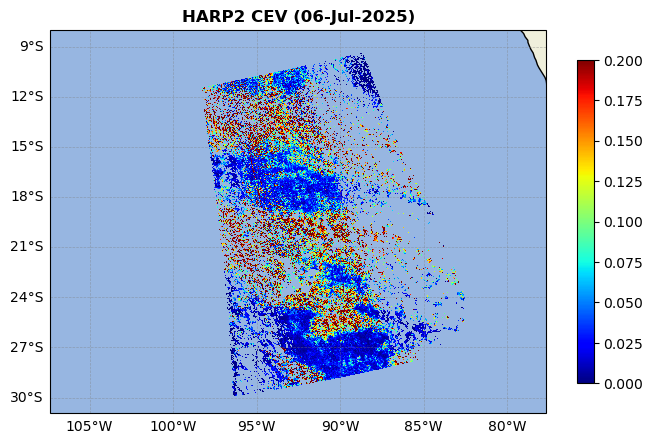

In [24]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap_name='jet'

data = np.where(mask_all, HARP2_CLD.retr.cloud_bow_droplet_effective_variance, np.nan)    

# fig,ax=plt.subplots()
mat = ax.pcolormesh(OCI_CLD.ds.longitude.values, OCI_CLD.ds.latitude.values, data, transform=ccrs.PlateCarree(),
                     cmap=cmap_name, vmin=0, vmax=0.2, shading="nearest", rasterized=True)
ax.set_aspect("equal")
ax.set_aspect("equal")
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('HARP2 CEV (06-Jul-2025)', fontsize=12, color='k', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
cax = plt.colorbar(mat, ax=ax, shrink=0.7)

print(f'CEV of pixel red: {HARP2_CLD.retr.cloud_bow_droplet_effective_variance[y0,x0].values:.3f}')
print(f'CEV of pixel black: {HARP2_CLD.retr.cloud_bow_droplet_effective_variance[y1,x1].values:.2f}')

CER at pixel [231, 292] red: 14.96 μm
CER at pixel [188, 289] black: 25.38 μm


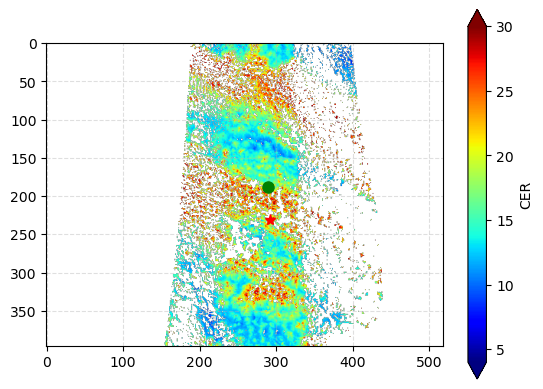

In [25]:
data = np.where(mask_all, OCI_CLD.ds.cer_21_water_cloud.values, np.nan)

# Extract CER at a pixel
cer_pixel = data[231, 292]
cer_pixel_n = data[188, 289] 
print(f"CER at pixel [231, 292] red: {cer_pixel:.2f} μm")
print(f"CER at pixel [188, 289] black: {cer_pixel_n:.2f} μm")

plt.figure()
img = plt.imshow(data[::-1], vmin=4, vmax=30, cmap='jet', rasterized=True)     
plt.plot(292, 231, marker='*', color='r', markersize=8)
plt.plot(289, 188, marker='o', color='g', markersize=8)
# plt.colorbar(img, extend='both', label='CER', ticks=np.arange(np.nanmin(data), np.nanmax(data) + 1, 5))
plt.colorbar(img, extend='both', label='CER')
plt.grid(linestyle="--", alpha=0.4)
plt.show() 